<a href="https://colab.research.google.com/github/harshitha24bad034-tech/harshitha24bad034_Exp2/blob/main/EX_2scenario_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd

# List files in the downloaded directory
files_in_dataset = os.listdir(path)
print("Files in the dataset directory:", files_in_dataset)

# Assuming there's a CSV file, let's try to load the first one found
csv_files = [f for f in files_in_dataset if f.endswith('.csv')]

if csv_files:
    data_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file_path)
    print("Data loaded successfully into a DataFrame. Here are the first 5 rows:")
    print(df.head())
    print("\nAnd here is some information about the DataFrame:")
    df.info()
else:
    print("No CSV files found in the downloaded dataset.")

In [1]:
import sys
!{sys.executable} -m pip install kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("debashis74017/lic-stock-price-data")

print("Path to dataset files:", path)

100%|██████████| 671k/671k [00:00<00:00, 72.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/debashis74017/lic-stock-price-data/versions/4


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)


In [4]:
import os
import pandas as pd

# List files in the downloaded directory to find the correct CSV
files_in_dataset = os.listdir(path)
csv_files = [f for f in files_in_dataset if f.endswith('.csv')]

if csv_files:
    # Use the first found CSV file
    data_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file_path)
    print("Data loaded successfully into a DataFrame. Here are the first 5 rows:")
    print(df.head())
    print("\nAnd here is some information about the DataFrame:")
    df.info()
else:
    print("No CSV files found in the downloaded dataset.")
    df = pd.DataFrame() # Initialize an empty DataFrame to avoid errors if no CSV is found

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/debashis74017/lic-stock-price-data/versions/4/LIC_stock_data.csv'

In [6]:
file_name = os.listdir(path)[0]
df = pd.read_csv(path + "/" + file_name)
df.head()


,date,open,high,low,close,volume
0,2022-05-17 09:42:00+05:30,872.0,872.0,872.0,872.0,3759243
1,2022-05-17 09:45:00+05:30,872.0,872.0,872.0,872.0,0
2,2022-05-17 09:48:00+05:30,872.0,872.0,872.0,872.0,0
3,2022-05-17 09:51:00+05:30,872.0,872.0,872.0,872.0,0
4,2022-05-17 09:54:00+05:30,872.0,872.0,872.0,872.0,0


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12616 entries, 0 to 12615
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    12616 non-null  object 
 1   open    12616 non-null  float64
 2   high    12616 non-null  float64
 3   low     12616 non-null  float64
 4   close   12616 non-null  float64
 5   volume  12616 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 591.5+ KB


In [8]:
df.describe()

,open,high,low,close,volume
count,12616.000000,12616.000000,12616.000000,12616.000000,1.261600e+04
mean,697.705445,698.218449,697.157645,697.677957,2.139556e+04
std,60.795765,60.930860,60.645472,60.788677,1.113899e+05
min,617.450000,618.000000,617.050000,617.200000,0.000000e+00
25%,662.000000,662.400000,661.500000,662.000000,4.293000e+03
50%,678.900000,679.300000,678.500000,678.875000,8.579000e+03
75%,707.150000,707.500000,706.650000,707.150000,1.834100e+04
max,913.350000,918.100000,902.750000,913.800000,1.000949e+07


In [10]:
df.columns


Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [11]:
df["Price_Movement"] = (df["close"] > df["open"]).astype(int)

df[["open", "close", "Price_Movement"]].head()


,open,close,Price_Movement
0,872.0,872.0,0
1,872.0,872.0,0
2,872.0,872.0,0
3,872.0,872.0,0
4,872.0,872.0,0


In [12]:
X = df[["open", "high", "low", "volume"]]
y = df["Price_Movement"]


In [13]:
X.isnull().sum()


,0
open,0
high,0
low,0
volume,0


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.5942947702060222
Precision: 0.9622641509433962
Recall   : 0.047530288909599254
F1 Score : 0.0905861456483126


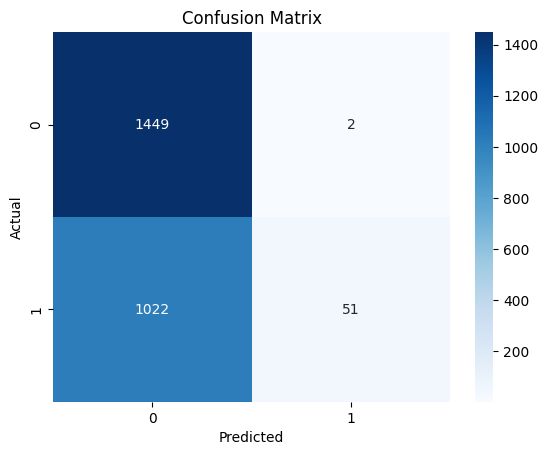

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


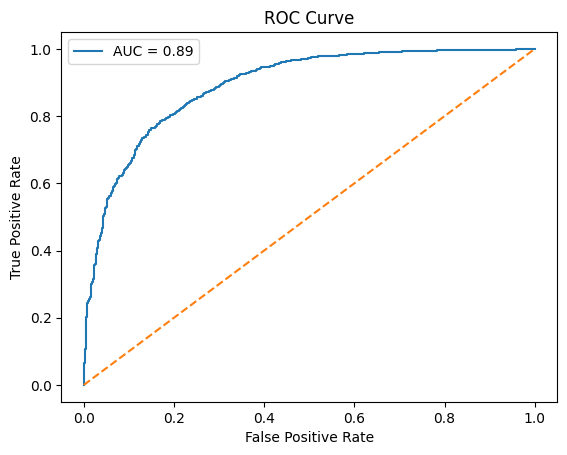

In [20]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [21]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": ["open", "high", "low", "volume"],
    "Coefficient": model.coef_[0]
})

feature_importance


,Feature,Coefficient
0,open,-13.407448
1,high,7.996232
2,low,5.412638
3,volume,-0.054727


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


In [23]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))


Optimized Accuracy: 0.7614896988906498
